包导入，matplotlib中文支持

In [15]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

# matplotlib 中文支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

输入图片：mana.jpg（RGB → 灰度）
卷积核：高斯模糊核（9×9，σ = 1.5）
目标：在已知模糊核下，从「模糊 + 噪声」图像中反卷积恢复原图

图像尺寸 = (553, 526)，像素范围 [0.000, 1.000]
带噪 SNR = 39.99 dB


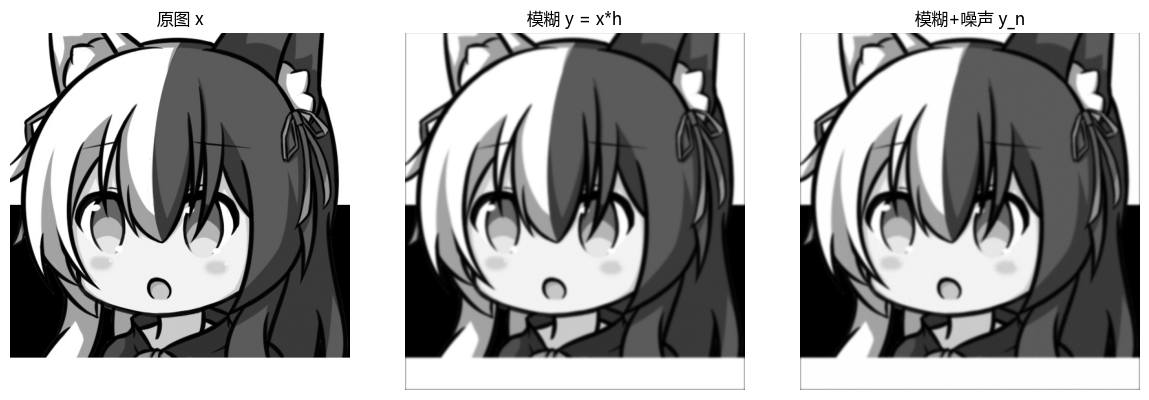

In [30]:
def snr_db(x, x_hat):
    """信噪比（dB）：SNR = 10*log10(||x||^2 / ||x - x_hat||^2)"""
    return 10 * np.log10(np.sum(x ** 2) / np.sum((x - x_hat) ** 2))


def gaussian_kernel(size, sigma):
    """生成归一化的二维高斯模糊核"""
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    return k / k.sum()


def add_noise(sig, snr_target=40.0, seed=42):
    """添加高斯白噪声，使带噪信号 SNR 达到 snr_target (dB)"""
    rng = np.random.default_rng(seed)
    p_sig = np.mean(sig ** 2)
    p_noise = p_sig / (10 ** (snr_target / 10))
    return sig + rng.normal(0.0, np.sqrt(p_noise), sig.shape)


# ---- 输入图片：mana.jpg，转灰度并归一化到 [0,1] ----
rgb = plt.imread('mana.jpg')     # 与笔记本同目录
if rgb.max() > 1.0:              # 部分 matplotlib 版本返回 [0,255] 整数
    rgb = rgb / 255.0
x = rgb.mean(axis=2)             # RGB → 灰度
print(f'图像尺寸 = {x.shape}，像素范围 [{x.min():.3f}, {x.max():.3f}]')

# ---- 卷积核：9×9 高斯模糊，σ = 1.5 ----
h = gaussian_kernel(9, 1.5)

# ---- 模糊 + 噪声（same 模式，保持尺寸不变）----
# 噪声取 40 dB：RL 对噪声极敏感，30 dB 下几乎无法恢复，40 dB 才能展示「早期迭代好、过迭代退化」
y = signal.fftconvolve(x, h, mode='same')
y_n = add_noise(y, 40.0)
print(f'带噪 SNR = {snr_db(y, y_n):.2f} dB')

# ---- 显示 原图 / 模糊 / 模糊+噪声（锁定显示范围 [0,1]）----
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(x, cmap='gray', vmin=0, vmax=1); axes[0].set_title('原图 x'); axes[0].axis('off')
axes[1].imshow(y, cmap='gray', vmin=0, vmax=1); axes[1].set_title('模糊 y = x*h'); axes[1].axis('off')
axes[2].imshow(y_n, cmap='gray', vmin=0, vmax=1); axes[2].set_title('模糊+噪声 y_n'); axes[2].axis('off')
plt.tight_layout()
plt.show()

如果希望恢复的信号/图像边缘清晰，或者信号本身具有稀疏性（如冲激序列反卷积），$L2$ 正则化会导致边缘过度平滑（毛刺没了，但边缘也模糊了）。此时会加入导数的 $L1$ 范数作为正则项：
Richardson-Lucy 迭代算法（常用于天文学和光学显微图像反卷积，基于泊松噪声模型）
1. Richardson-Lucy 迭代算法 (RL Deconvolution)核心思想：基于泊松噪声模型（Poisson Noise）推导出的极大似然估计。计算公式：$$\hat{x}^{(k+1)} = \hat{x}^{(k)} \cdot \left( h^* * \frac{y}{h * \hat{x}^{(k)}} \right)$$其中 $h^*$ 是卷积核的翻转（伴随算子），操作全是普通的卷积和逐元素除法，不需要对矩阵求逆。特点：天然保证非负性约束（$\hat{x} \ge 0$），非常适合图像能量、光谱或声音能量包络的恢复。迭代早期效果极好，但迭代次数过多会导致高频噪声放大（需要早停策略）。

In [36]:
def richardson_lucy(y, h, num_iter=30, eps=1e-6):
    """Richardson-Lucy 迭代反卷积（基于泊松噪声模型）

    x_{k+1} = x_k · (h* ⊛ (y / (h ⊛ x_k)))
    h* 为 h 的翻转（伴随算子）；全程只有卷积和逐元素乘除，天然保证非负。
    泊松模型要求输入非负，故先裁剪 y ≥ 0（高斯噪声带来的负值会破坏除法稳定性）；
    eps 对 y_est 做下限保护，防止边缘（补零卷积）除零产生异常极大值。
    """
    y = np.clip(y, 0.0, None)     # 泊松模型要求非负输入
    h_flip = h[::-1, ::-1]
    x_hat = y.copy()
    for _ in range(num_iter):
        est = signal.fftconvolve(x_hat, h, mode='same')   # h ⊛ x_k
        ratio = y / np.maximum(est, eps)                  # 防边缘除零爆炸
        corr = signal.fftconvolve(ratio, h_flip, mode='same')  # h* ⊛ (y/h⊛x_k)
        x_hat = x_hat * corr
    return x_hat

Richardson-Lucy（2 次迭代）：SNR = 19.67 dB


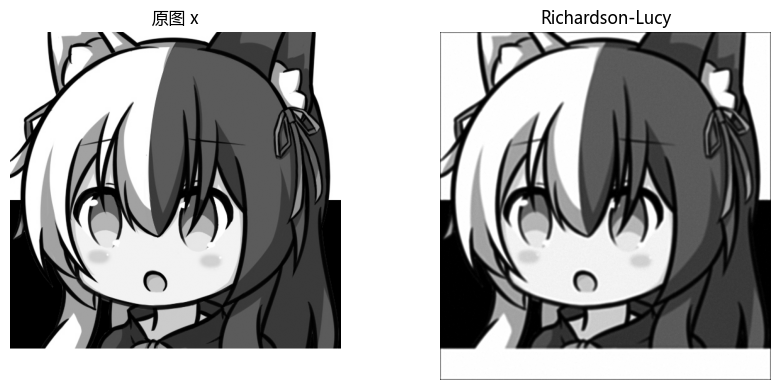

In [57]:
# 迭代次数取扫描最优值 2（高斯噪声下 RL 需激进早停，见下方扫描）
x_rl = richardson_lucy(y_n, h, num_iter=2)
print(f'Richardson-Lucy（2 次迭代）：SNR = {snr_db(x, x_rl):.2f} dB')

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(x, cmap='gray', vmin=0, vmax=1); axes[0].set_title('原图 x'); axes[0].axis('off')
axes[1].imshow(x_rl, cmap='gray', vmin=0, vmax=1); axes[1].set_title('Richardson-Lucy'); axes[1].axis('off')
plt.tight_layout()
plt.show()

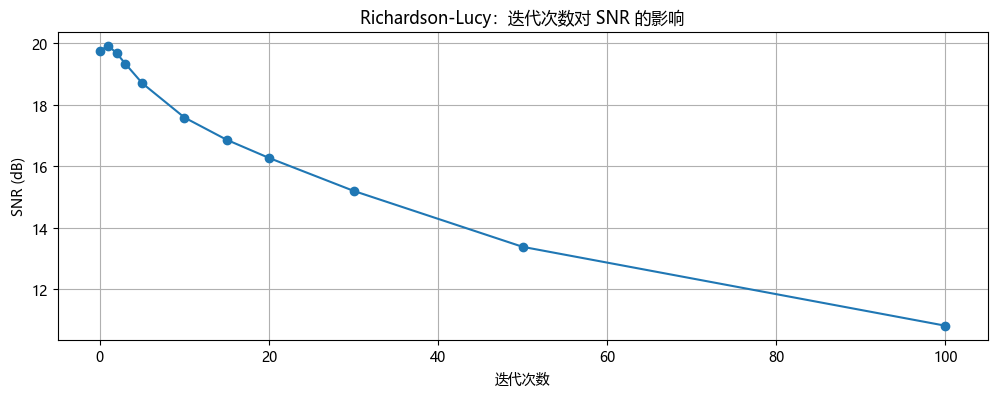

最优迭代次数 = 1，SNR = 19.92 dB


In [46]:
# ---- RL 迭代次数扫描：迭代过多会放大高频噪声（需要早停策略）----
iters = [0, 1, 2, 3, 5, 10, 15, 20, 30, 50, 100]
snrs = [snr_db(x, richardson_lucy(y_n, h, it)) for it in iters]

plt.figure(figsize=(12, 4))
plt.plot(iters, snrs, 'o-')
plt.xlabel('迭代次数')
plt.ylabel('SNR (dB)')
plt.title('Richardson-Lucy：迭代次数对 SNR 的影响')
plt.grid(True)
plt.show()

best = int(np.argmax(snrs))
print(f'最优迭代次数 = {iters[best]}，SNR = {snrs[best]:.2f} dB')

# 2. 全变差（Total Variation, TV）正则化反卷积
TV 正则化使用导数的 $L1$ 范数（允许少量大梯度 → 保留边缘，同时抑制噪声）：
$$\min_x \frac{1}{2}\Vert{}Ax - y\Vert{}_2^2 + \lambda \sum_{ij}\sqrt{(\nabla_x x)^2 + (\nabla_y x)^2}$$
用 Chambolle-Pock 原始-对偶算法求解，卷积算子 $A$ 及其伴随 $A^*$（翻转核）都用 FFT 实现。

In [32]:
def grad(x):
    """前向差分梯度，返回 (gx, gy)，边界外视为 0"""
    gx = np.zeros_like(x)
    gy = np.zeros_like(x)
    gx[:, :-1] = x[:, 1:] - x[:, :-1]   # x 方向（水平）
    gy[:-1, :] = x[1:, :] - x[:-1, :]   # y 方向（垂直）
    return gx, gy


def div(px, py):
    """梯度算子的负伴随（散度）：<∇x, p> = <x, -div p>"""
    out = np.zeros_like(px)
    out[1:, :] += px[:-1, :] - px[1:, :]
    out[0, :] += -px[0, :]
    out[:, 1:] += py[:, :-1] - py[:, 1:]
    out[:, 0] += -py[:, 0]
    return out


def deconv_tv(y, h, lam, num_iter=200):
    """全变差正则化反卷积：min_x 1/2||Ax - y||^2 + λ·TV(x)

    Chambolle-Pock 原始-对偶算法（各向同性 TV，TV = Σ sqrt((∇x_x)² + (∇x_y)²)）。
    A、A* 均为 'same' 模式的 FFT 卷积。
    """
    h_flip = h[::-1, ::-1]

    # 步长：||K||² ≤ ||A||² + ||∇||² ≤ 1 + 8 = 9，取 στ < 1/9
    sigma = tau = 0.99 / np.sqrt(9.0)
    theta = 1.0

    x_hat = y.copy()
    xbar = x_hat.copy()
    pA = np.zeros_like(y)     # 保真项对偶变量
    pqx = np.zeros_like(y)    # TV 对偶变量（水平）
    pqy = np.zeros_like(y)    # TV 对偶变量（垂直）

    for _ in range(num_iter):
        # ---- 对偶更新 ----
        Axbar = signal.fftconvolve(xbar, h, mode='same')
        gxbar = grad(xbar)
        # 保真项：prox_{σf*}(v) = (v - σy)/(1+σ)，v = pA + σAxbar
        pA = (pA + sigma * (Axbar - y)) / (1 + sigma)
        # TV：投影到每个像素 ||q||₂ ≤ λ
        vqx = pqx + sigma * gxbar[0]
        vqy = pqy + sigma * gxbar[1]
        nrm = np.sqrt(vqx ** 2 + vqy ** 2)
        scale = np.minimum(1.0, lam / (nrm + 1e-12))
        pqx = vqx * scale
        pqy = vqy * scale

        # ---- 原始更新：x ← x - τ(A* pA - div q) ----
        Apx = signal.fftconvolve(pA, h_flip, mode='same')
        x_new = x_hat - tau * (Apx - div(pqx, pqy))

        # ---- 外推 ----
        xbar = x_new + theta * (x_new - x_hat)
        x_hat = x_new

    return x_hat

TV 反卷积（λ=1e-5, 200 次迭代）：SNR = 25.08 dB


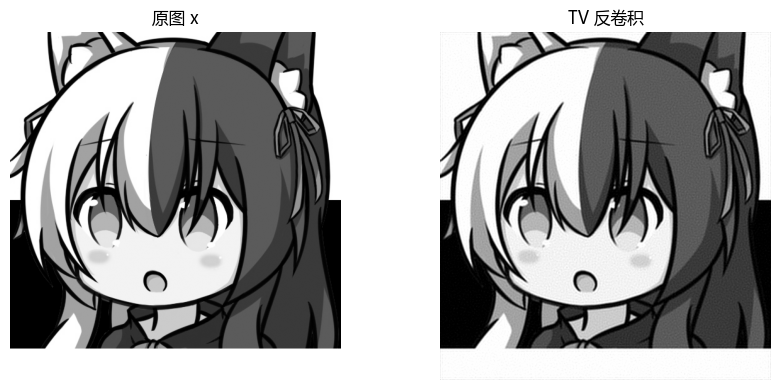

In [41]:
# λ 取扫描结果：λ≤1e-4 时 SNR 平坦（~24.9 dB），取 1e-5 兼顾边缘正则化
x_tv = deconv_tv(y_n, h, lam=1e-5, num_iter=200)
print(f'TV 反卷积（λ=1e-5, 200 次迭代）：SNR = {snr_db(x, x_tv):.2f} dB')

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(x, cmap='gray', vmin=0, vmax=1); axes[0].set_title('原图 x'); axes[0].axis('off')
axes[1].imshow(x_tv, cmap='gray', vmin=0, vmax=1); axes[1].set_title('TV 反卷积'); axes[1].axis('off')
plt.tight_layout()
plt.show()

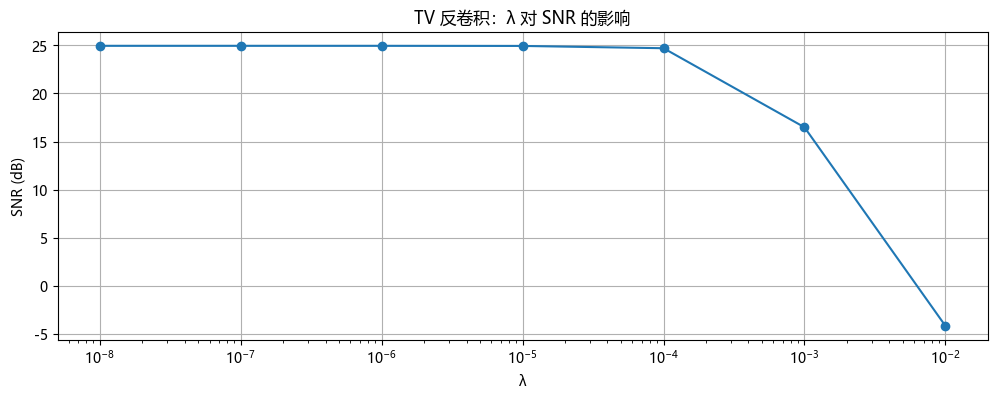

最优 λ = 1.00e-08，SNR = 24.95 dB


In [39]:
# ---- TV λ 扫描：正则化强度对结果的影响 ----
# 数据已归一化到 [0,1]，保真项 ||Ax-y||² 变小约 65000 倍，最优 λ 应相应缩小
lams = np.logspace(-8, -2, 7)
snrs_tv = [snr_db(x, deconv_tv(y_n, h, lam, num_iter=150)) for lam in lams]

plt.figure(figsize=(12, 4))
plt.semilogx(lams, snrs_tv, 'o-')
plt.xlabel('λ')
plt.ylabel('SNR (dB)')
plt.title('TV 反卷积：λ 对 SNR 的影响')
plt.grid(True)
plt.show()

best = int(np.argmax(snrs_tv))
print(f'最优 λ = {lams[best]:.2e}，SNR = {snrs_tv[best]:.2f} dB')

方法                  SNR (dB)
--------------------------------
Richardson-Lucy        19.67
TV 反卷积                 25.08


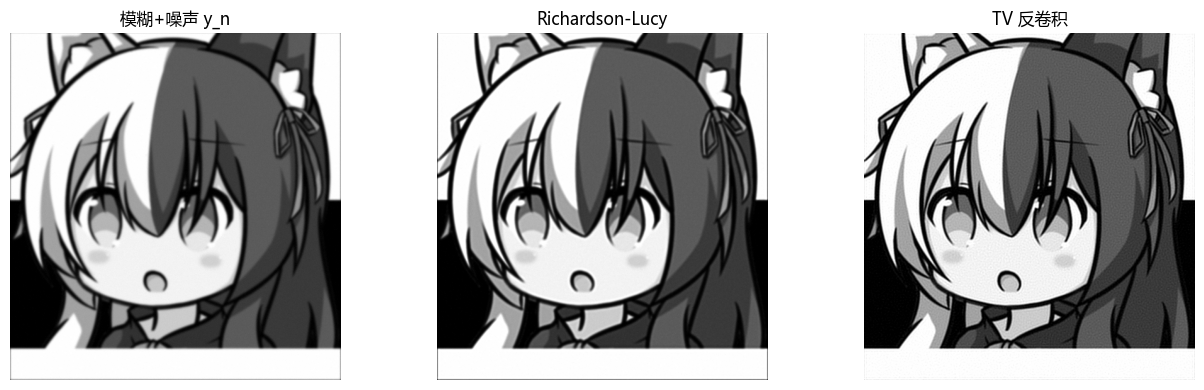

In [44]:
# ---- 各方法 SNR 汇总 ----
rows = [
    ('Richardson-Lucy', snr_db(x, x_rl)),
    ('TV 反卷积', snr_db(x, x_tv)),
]
print('方法                  SNR (dB)')
print('-' * 32)
for name, snr in rows:
    print(f'{name:<18}{snr:>10.2f}')

# ---- 结果对比（锁定显示范围 [0,1]）----
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (img, title) in zip(axes, [
        (y_n, '模糊+噪声 y_n'),
        (x_rl, 'Richardson-Lucy'),
        (x_tv, 'TV 反卷积')]):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

# 结论
TV牛逼，lucy看起来比TV有模糊的地方，但是？！快快！？